In [17]:
import os
import json
from glob import glob
from collections import defaultdict

import numpy as np
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4

DINO_FOLDER = "dataset/dinosaur"

MODEL_PATH = "models/stage2_dino_species.keras"
CLASS_MAP_PATH = "models/stage2_dino_classes.json"

In [2]:
X, y = [], []
class_to_idx = {}
idx_to_class = {}

def get_base_class(folder_name):
    return folder_name.split("_")[0]

grouped_folders = defaultdict(list)

In [3]:
for sub in os.listdir(DINO_FOLDER):
    full_path = os.path.join(DINO_FOLDER, sub)
    if os.path.isdir(full_path):
        base_class = get_base_class(sub)
        grouped_folders[base_class].append(full_path)

class_names = sorted(grouped_folders.keys())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

In [4]:
print("Визначенні класи:")
for cls, paths in grouped_folders.items():
    print(f"  {cls}: {len(paths)} папки")

Визначенні класи:
  Allosaurus: 1 папки
  Ankylosaurus: 2 папки
  Apatosaurus: 1 папки
  Archaeopteryx: 1 папки
  Argentinosaurus: 1 папки
  Atrociraptor: 1 папки
  Barosaurus: 1 папки
  Baryonyx: 1 папки
  Brachiosaurus: 2 папки
  Brontosaurus: 1 папки
  Carnotaurus: 1 папки
  Ceratosaurus: 1 папки
  Compsognathus: 2 папки
  Corythosaurus: 2 папки
  Dilophosaurus: 2 папки
  Dimetrodon: 1 папки
  Dimorphodon: 2 папки
  Diplodocus: 1 папки
  Europasaurus: 1 папки
  Gallimimus: 2 папки
  Giganotosaurus: 1 папки
  Iguanodon: 1 папки
  Lystrosaurus: 1 папки
  Maiasaura: 1 папки
  Mamenchisaurus: 1 папки
  Microceratus: 2 папки
  Mosasaurus: 1 папки
  Nasutoceratops: 1 папки
  Nodosaurus: 1 папки
  Oviraptor: 1 папки
  Pachycephalosaurus: 2 папки
  Parasaurolophus: 2 папки
  Pteranodon: 1 папки
  Pterodactyl: 1 папки
  Pyroraptor: 1 папки
  Quetzalcoatlus: 1 папки
  Sinoceratops: 1 папки
  Spinosaurus: 2 папки
  Stegosaurus: 2 папки
  Stygimoloch: 1 папки
  Styracosaurus: 1 папки
  Therizin

In [5]:
for cls, folders in grouped_folders.items():
    label = class_to_idx[cls]
    for folder in folders:
        paths = glob(f"{folder}/**/*.*", recursive=True)
        for path in tqdm(paths, desc=f"Loading {cls}"):
            try:
                img = Image.open(path).convert("RGB").resize(IMG_SIZE)
                X.append(np.array(img))
                y.append(label)
            except (UnidentifiedImageError, OSError):
                pass

X = np.array(X, dtype="float32") / 255.0
y = np.array(y, dtype=np.int32)

print("\Загальна кількість картинок:", len(X))
print("Класи:", class_to_idx)

Loading Velociraptor: 100%|██████████| 158/158 [00:04<00:00, 38.79it/s]


\Загальна кількість картинок: 6690
Класи: {'Allosaurus': 0, 'Ankylosaurus': 1, 'Apatosaurus': 2, 'Archaeopteryx': 3, 'Argentinosaurus': 4, 'Atrociraptor': 5, 'Barosaurus': 6, 'Baryonyx': 7, 'Brachiosaurus': 8, 'Brontosaurus': 9, 'Carnotaurus': 10, 'Ceratosaurus': 11, 'Compsognathus': 12, 'Corythosaurus': 13, 'Dilophosaurus': 14, 'Dimetrodon': 15, 'Dimorphodon': 16, 'Diplodocus': 17, 'Europasaurus': 18, 'Gallimimus': 19, 'Giganotosaurus': 20, 'Iguanodon': 21, 'Lystrosaurus': 22, 'Maiasaura': 23, 'Mamenchisaurus': 24, 'Microceratus': 25, 'Mosasaurus': 26, 'Nasutoceratops': 27, 'Nodosaurus': 28, 'Oviraptor': 29, 'Pachycephalosaurus': 30, 'Parasaurolophus': 31, 'Pteranodon': 32, 'Pterodactyl': 33, 'Pyroraptor': 34, 'Quetzalcoatlus': 35, 'Sinoceratops': 36, 'Spinosaurus': 37, 'Stegosaurus': 38, 'Stygimoloch': 39, 'Styracosaurus': 40, 'Therizinosaurus': 41, 'Triceratops': 42, 'Troodon': 43, 'Tyrannosaurus': 44, 'Velociraptor': 45}


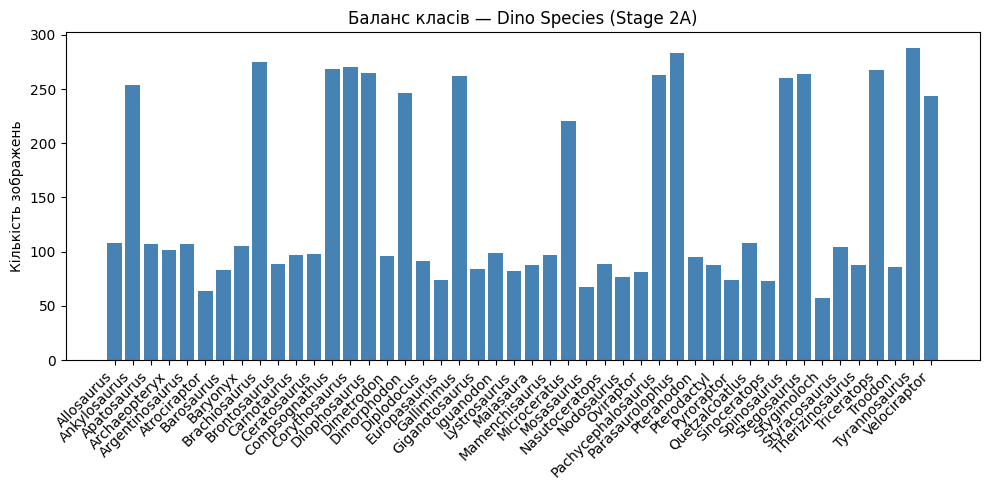

In [6]:
class_counts = {cls: 0 for cls in class_to_idx.keys()}

for label in y:
    class_name = idx_to_class[label]
    class_counts[class_name] += 1

labels = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Баланс класів — Dino Species (Stage 2A)")
plt.ylabel("Кількість зображень")
plt.tight_layout()
plt.show()

In [7]:
os.makedirs("models", exist_ok=True)
with open(CLASS_MAP_PATH, "w", encoding="utf-8") as f:
    json.dump(idx_to_class, f, indent=2)

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [9]:
train_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_gen = ImageDataGenerator()

train_flow = train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_flow = val_gen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [ ]:
def create_model(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, 3, padding="same", input_shape=(*IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizers.Adam(LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = create_model(len(class_names))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 46)             │        11,822 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,724,078 (40.91 MB)

 Trainable params: 10,723,118 (40.91 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

In [21]:
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/50
74/74 - 118s - 2s/step - accuracy: 0.0478 - loss: 3.9572 - val_accuracy: 0.0140 - val_loss: 3.9902 - learning_rate: 1.0000e-04
Epoch 2/50
74/74 - 115s - 2s/step - accuracy: 0.0901 - loss: 3.5817 - val_accuracy: 0.0179 - val_loss: 4.1130 - learning_rate: 1.0000e-04
Epoch 3/50
74/74 - 116s - 2s/step - accuracy: 0.1095 - loss: 3.4252 - val_accuracy: 0.0179 - val_loss: 4.0080 - learning_rate: 1.0000e-04
Epoch 4/50


KeyboardInterrupt: 

In [ ]:
print("\nПеревірка на тестових даних:")
model.evaluate(X_test, y_test, verbose=2)

In [ ]:
model.save(MODEL_PATH)